
# Particle Filter Animation: Leaching Reactor

*Generated using Claude Sonnet 5 ([see chat](https://claude.ai/share/03d5becf-101a-4e4d-87f4-99ac93311acf)), then modified for clarity.*

*Companion to* `leaching_ekf.ipynb` *— same model, same scenario, illustrated with a particle filter instead of the EKF.*

This notebook builds, for a single user-chosen time step `step_idx`, an animated 6-step picture of what a particle filter actually does under the hood:

1. Sampling — draw particles from the current belief.
2. Propagate — push each particle through the (stochastic) dynamics.
3. Observation model — map each propagated particle through $h(x)$.
4. Measure — compare predictions to the real measurement; weight particles by likelihood.
5. Update — form a new belief (here: fit a Gaussian to the weighted particles — a Gaussian particle filter, closely related to an ensemble Kalman filter, not a traditional particle filter) and let the old particles fade.
6. Repeat — sample fresh particles from the new belief.

In [1]:
import numpy as np
import jax.numpy as jnp
from jax import vmap
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

np.random.seed(0)



## Model

*Reused from* `leaching_ekf.ipynb`


$$
\frac{dC_{\textrm{Cu}}^{(s)}}{dt}  =  \frac{Q}{V}\big(C_{\textrm{Cu},in}^{(s)} - C_{\textrm{Cu}}^{(s)}\big) -r \\[8pt]
\frac{dC_{\textrm{Cu}}^{(aq)}}{dt} = -\frac{Q}{V} C_{\textrm{Cu}}^{(aq)} + r \\[8pt]
\frac{dC_{\textrm{H}}}{dt}         =  \frac{Q}{V}\big(C_{\textrm{H},in} - C_{\textrm{H}}\big) - \gamma\, r + \frac{q}{V}  \\[12pt]
r = k\, C_{\textrm{H}}\, C_{\textrm{Cu}}^{(s)} \\[12pt]
pH = -\log_{10}\!\big(C_{\textrm{H}}\big) + v, \qquad v \sim \mathcal{N}(0, R)
$$

In [2]:
params = dict(
    Q=1.0,           # slurry volumetric flow, in = out [m^3/min]
    V=10.0,          # reactor volume [m^3]
    k=0.05,          # reaction rate constant [1/(min * (mol/m^3))]
    gamma=1.0,       # stoichiometric acid consumption per unit Cu dissolved
    C_H_in=0.05,     # acid concentration in slurry feed [mol/m^3]
    C_Cu_s_in=8.0,   # solid-phase Cu concentration in feed [mol/m^3]
)
p = tuple(params.values())

def f(x, u, p):
    C_Cu, C_H, C_Cu_s = x
    q = u
    Q, V, k, gamma, C_H_in, C_Cu_s_in = p

    r = k * C_H * C_Cu_s

    dC_Cu = -(Q / V) * C_Cu + r
    dC_H = (Q / V) * (C_H_in - C_H) - gamma * r + (q / V)
    dC_Cu_s = (Q / V) * (C_Cu_s_in - C_Cu_s) - r

    return jnp.array([dC_Cu, dC_H, dC_Cu_s])

def h(x):
    C_Cu, C_H, C_Cu_s = x
    return jnp.array([-jnp.log10(C_H)])

def u_profile(t):
    return 2.5 if t < 60.0 else 1.25   # [mol/min], step at t = 60 min

# vmapped versions: evaluate f and h for a whole (N, 3) batch of particles at once
f_vec = vmap(f, in_axes=(0, None, None))
h_vec = vmap(h, in_axes=0)


Simulate the true plant and generate noisy pH measurements

In [3]:
def plant_ode(t, x, p):
    return np.array(f(jnp.array(x), u_profile(t), p))

T_final = 180.0
t_grid = np.linspace(0.0, T_final, 2000)
t_meas = np.arange(0.0, T_final + 2.0, 2.0)

R = np.array([[0.05]])                     # pH measurement noise variance
Q_proc = np.diag([1e-2, 1e-2, 1e-2])       # process noise covariance (continuous-time)

x0_true = np.array([2.0, 0.6, 6.0])
sol = solve_ivp(plant_ode, (t_grid[0], t_grid[-1]), x0_true, t_eval=t_grid, args=(p,))
x_true = sol.y.T

idx_meas = np.searchsorted(t_grid, t_meas)
sigma_meas = np.sqrt(R[0, 0])
y_true_full = np.array([h(jnp.array(x_true[i]))[0] for i in range(len(t_grid))])
y_meas = np.array([y_true_full[idx] for idx in idx_meas]) + sigma_meas * np.random.randn(len(t_meas))


## Particle filter

In [4]:
def rk4_step_vec(X, u, p, dt):
    """RK4 step for a whole (N,3) batch of particles at once (via vmap)."""
    k1 = f_vec(X, u, p)
    k2 = f_vec(X + 0.5 * dt * k1, u, p)
    k3 = f_vec(X + 0.5 * dt * k2, u, p)
    k4 = f_vec(X + dt * k3, u, p)
    return X + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def propagate_particles(X0, u, p, Qc, dt, n_sub, rng):
    """Propagate all particles from t to t+dt, returning the FULL trajectory
    (n_sub+1, N, 3) so we can animate the path, not just the endpoint."""
    N, n = X0.shape
    traj = np.zeros((n_sub + 1, N, n))
    traj[0] = X0
    dt_sub = dt / n_sub
    L = np.linalg.cholesky(Qc + 1e-12 * np.eye(n))

    X = jnp.array(X0)
    for s in range(1, n_sub + 1):
        X = rk4_step_vec(X, u, p, dt_sub)
        noise = (rng.standard_normal((N, n)) @ L.T) * np.sqrt(dt_sub)
        X = jnp.array(np.maximum(np.array(X) + noise, 1e-8))
        traj[s] = np.array(X)
    return traj


def compute_weights(y_pred, y_meas_k, Rm):
    sigma2 = Rm[0, 0]
    logw = -0.5 * (y_meas_k - y_pred) ** 2 / sigma2
    logw -= logw.max()          # normalize for numerical stability
    w = np.exp(logw)
    return w / w.sum()


def weighted_mean_cov(X, w):
    mean = np.average(X, axis=0, weights=w)
    Xc = X - mean
    cov = (Xc.T * w) @ Xc + 1e-8 * np.eye(X.shape[1])
    return mean, cov


def run_particle_filter(x0_hat, P0, t_meas, y_meas, p, Qc, Rm, N=100, n_sub=20, seed=0):
    """Runs the Gaussian particle filter across all measurement times, storing
    everything needed to regenerate the 5-step figure set for ANY chosen
    transition afterward, without re-running the filter."""
    rng = np.random.default_rng(seed)
    x_hat, P = x0_hat.copy(), P0.copy()
    history = []

    for k in range(1, len(t_meas)):
        t_prev, t_next = t_meas[k - 1], t_meas[k]
        dt = t_next - t_prev
        u = u_profile(t_prev)

        # 1. Sample
        X0 = np.maximum(rng.multivariate_normal(x_hat, P, size=N), 1e-8)

        # 2. Propagate
        traj = propagate_particles(X0, u, p, Qc, dt, n_sub, rng)
        Xk = traj[-1]

        # 3. Observation model
        y_pred = np.array(h_vec(jnp.array(Xk)))[:, 0]

        # 4. Measure -> weights
        w = compute_weights(y_pred, y_meas[k], Rm)

        # 5. Update -> new Gaussian belief
        x_hat_new, P_new = weighted_mean_cov(Xk, w)

        history.append(dict(
            t_prev=t_prev, t_next=t_next, dt=dt,
            x_hat_prior=x_hat.copy(), P_prior=P.copy(),
            X0=X0, traj=traj, Xk=Xk,
            y_pred=y_pred, y_meas=y_meas[k], w=w,
            x_hat_post=x_hat_new.copy(), P_post=P_new.copy(),
        ))

        x_hat, P = x_hat_new, P_new   # 6. Repeat

    return history


Run the particle filter over the entire simulation time

In [5]:
x0_hat = np.array([0.0, 2.0, 1.0])          # same deliberately wrong guess as the EKF
P0 = np.diag([1.0, 0.1, 4.0])

history = run_particle_filter(x0_hat, P0, t_meas, y_meas, p, Q_proc, R, N=100, n_sub=20, seed=0)
print(f"Particle filter ran for {len(history)} steps.")


Particle filter ran for 90 steps.


## Visualization

In [18]:
state_labels = [r"$C_{Cu}^{(aq)}$", r"$C_H$", r"$C_{Cu}^{(s)}$"]
panel_pos = [(0, 0), (0, 1), (1, 0)]   # state panels; (1,1) is reserved for pH

OUT = "./figures"


def new_figure(step, window=20.0):
    """Common 2x2 layout with truth + EKF reference, zoomed to a window
    around the current transition."""
    t_c = step["t_next"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    t_lo, t_hi = t_c - window, t_c + window
    mask = (t_grid >= t_lo) & (t_grid <= t_hi)
    mmask = (t_meas >= t_lo) & (t_meas <= t_hi)

    for i, (r, c) in enumerate(panel_pos):
        ax = axes[r, c]
        ax.plot(t_grid[mask], x_true[mask, i], "k-", lw=1.2, label="truth")
        ax.set_xlim(t_lo, t_hi)
        ax.set_ylabel(state_labels[i])
        ax.set_xlabel("time [min]")

    ax_ph = axes[1, 1]
    ax_ph.plot(t_grid[mask], y_true_full[mask], "k-", lw=1, alpha=0.5, label="true pH")
    ax_ph.plot(t_meas[mmask], y_meas[mmask], "r.", ms=4, alpha=0.35, label="pH meas. (hist.)")
    ax_ph.set_xlim(t_lo, t_hi)
    ax_ph.set_ylabel("pH")
    ax_ph.set_xlabel("time [min]")

    return fig, axes


def jitter(n, scale=0.6, seed=1):
    return (np.random.default_rng(seed).random(n) - 0.5) * scale


### Step 1 — Sampling (static)

In [19]:
def plot_sampling(step, fname):
    fig, axes = new_figure(step)
    t_prev = step["t_prev"]
    x_hat, P = step["x_hat_prior"], step["P_prior"]
    std = np.sqrt(np.diag(P))
    X0 = step["X0"]
    jit = jitter(X0.shape[0])

    for i, (r, c) in enumerate(panel_pos):
        ax = axes[r, c]
        ax.errorbar([t_prev], [x_hat[i]], yerr=[1.96 * std[i]], fmt="o", color="darkorange",
                    capsize=4, elinewidth=2, markersize=5, zorder=6, label="95% CI (prior)")
        ax.scatter(t_prev + jit, X0[:, i], color="C1", s=12, alpha=0.6, zorder=5, label="particles")

    axes[0, 0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Step 1 -- Sampling  (t = {t_prev:.0f} min)")
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.close(fig)


### Step 2 — Propagate (animated)

In [20]:
def make_propagate_gif(step, fname, fps=10):
    fig, axes = new_figure(step)
    traj = step["traj"]                     # (n_sub+1, N, 3)
    n_sub = traj.shape[0] - 1
    N = traj.shape[1]
    t_sub = np.linspace(step["t_prev"], step["t_next"], n_sub + 1)

    scat, lines = [], []
    for i, (r, c) in enumerate(panel_pos):
        ax = axes[r, c]
        sc = ax.scatter(np.full(N, t_sub[0]), traj[0, :, i], color="C1", s=14, zorder=5)
        scat.append(sc)
        ln = [ax.plot([], [], color="gray", lw=0.6, alpha=0.5, zorder=1)[0] for _ in range(N)]
        lines.append(ln)

    fig.suptitle("Step 2 -- Propagate")
    fig.tight_layout()

    def update(frame):
        artists = []
        for i in range(3):
            scat[i].set_offsets(np.column_stack([np.full(N, t_sub[frame]), traj[frame, :, i]]))
            artists.append(scat[i])
            for j in range(N):
                lines[i][j].set_data(t_sub[:frame + 1], traj[:frame + 1, j, i])
            artists.extend(lines[i])
        return artists

    ani = animation.FuncAnimation(fig, update, frames=n_sub + 1, blit=False)
    ani.save(fname, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)


### Step 3 — Observation model (static)

In [21]:
def plot_observation(step, fname):
    fig, axes = new_figure(step)
    t_next = step["t_next"]
    Xk, y_pred = step["Xk"], step["y_pred"]
    jit = jitter(Xk.shape[0])

    for i, (r, c) in enumerate(panel_pos):
        axes[r, c].scatter(t_next + jit, Xk[:, i], color="C1", s=12, alpha=0.6, zorder=5, label="particles")

    axes[1, 1].scatter(t_next + jit, y_pred, color="gold", edgecolor="k", linewidth=0.3,
                        s=16, alpha=0.85, zorder=5, label="predicted pH per particle")
    axes[1, 1].legend(fontsize=7, loc="upper left")

    fig.suptitle(f"Step 3 -- Observation model  (t = {t_next:.0f} min)")
    fig.tight_layout()
    fig.savefig(fname, dpi=150)
    plt.close(fig)


### Step 4 — Measure & weight (animated)

In [22]:
def make_measure_gif(step, fname, fps=8, n_hold=5, n_resize=15):
    fig, axes = new_figure(step)
    t_next = step["t_next"]
    Xk, y_pred, w = step["Xk"], step["y_pred"], step["w"]
    y_meas_k = step["y_meas"]
    jit = jitter(Xk.shape[0])

    s0 = 12.0
    s_min, s_max = 2.0, 60.0
    s_final = s_min + (s_max - s_min) * (w / w.max())

    state_scat = []
    for i, (r, c) in enumerate(panel_pos):
        sc = axes[r, c].scatter(t_next + jit, Xk[:, i], color="C1",
                                 s=np.full(len(w), s0), alpha=0.7, zorder=5)
        state_scat.append(sc)
    ph_scat = axes[1, 1].scatter(t_next + jit, y_pred, color="gold", edgecolor="k",
                                  linewidth=0.3, s=np.full(len(w), s0), alpha=0.9, zorder=5)

    sigma = np.sqrt(R[0, 0])
    axes[1, 1].errorbar([t_next], [y_meas_k], yerr=[1.96 * sigma], fmt="o", color="red",
                         capsize=4, elinewidth=2, markersize=6, zorder=6, label="measurement (95% CI)")
    axes[1, 1].legend(fontsize=7, loc="upper left")
    fig.suptitle("Step 4 -- Measure & weight")
    fig.tight_layout()

    n_frames = n_hold + n_resize

    def update(frame):
        if frame < n_hold:
            s = np.full(len(w), s0)
        else:
            a = min((frame - n_hold + 1) / n_resize, 1.0)
            s = s0 + (s_final - s0) * a
        for sc in state_scat:
            sc.set_sizes(s)
        ph_scat.set_sizes(s)
        return state_scat + [ph_scat]

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=False)
    ani.save(fname, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)


### Step 5 — Update (animated)

In [23]:
def make_update_gif(step, fname, fps=8, n_frames=20):
    fig, axes = new_figure(step)
    t_next = step["t_next"]
    Xk, y_pred, w = step["Xk"], step["y_pred"], step["w"]
    x_hat_post, P_post = step["x_hat_post"], step["P_post"]
    std_post = np.sqrt(np.diag(P_post))
    jit = jitter(Xk.shape[0])

    s_min, s_max = 2.0, 60.0
    s_final = s_min + (s_max - s_min) * (w / w.max())

    state_scat = []
    for i, (r, c) in enumerate(panel_pos):
        sc = axes[r, c].scatter(t_next + jit, Xk[:, i], color="C1", s=s_final, alpha=0.8, zorder=5)
        state_scat.append(sc)
    ph_scat = axes[1, 1].scatter(t_next + jit, y_pred, color="gold", edgecolor="k",
                                  linewidth=0.3, s=s_final, alpha=0.9, zorder=5)

    ci_artists = []
    for i, (r, c) in enumerate(panel_pos):
        eb = axes[r, c].errorbar([t_next], [x_hat_post[i]], yerr=[1.96 * std_post[i]], fmt="o",
                                  color="darkorange", capsize=4, elinewidth=2, markersize=5,
                                  zorder=6, alpha=0)
        ci_artists.append(eb)

    fig.suptitle("Step 5 -- Update")
    fig.tight_layout()

    def set_errorbar_alpha(eb, alpha):
        eb[0].set_alpha(alpha)
        for coll in eb[1]:
            coll.set_alpha(alpha)
        for coll in eb[2]:
            coll.set_alpha(alpha)

    def update(frame):
        a = frame / (n_frames - 1)
        fade, grow = max(0.0, 1.0 - a), min(1.0, a)
        for sc in state_scat:
            sc.set_alpha(fade * 0.8)
        ph_scat.set_alpha(fade * 0.9)
        for eb in ci_artists:
            set_errorbar_alpha(eb, grow)
        return state_scat + [ph_scat]

    ani = animation.FuncAnimation(fig, update, frames=n_frames, blit=False)
    ani.save(fname, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)



## Generate the figure set for one chosen step

Set `step_idx` below (0 = the very first transition, i.e. $t=0\to 2$ min) to
pick which transition to illustrate, then run the cell. All 5 files are
written to `/mnt/user-data/outputs/` and can be pasted directly into
PowerPoint (the 3 GIFs autoplay once inserted).


In [24]:
step_idx = 20          # <-- choose which transition to visualize
step = history[step_idx]

plot_sampling(step, f"{OUT}/pf_step1_sampling.png")
make_propagate_gif(step, f"{OUT}/pf_step2_propagate.gif")
plot_observation(step, f"{OUT}/pf_step3_observation.png")
make_measure_gif(step, f"{OUT}/pf_step4_measure.gif")
make_update_gif(step, f"{OUT}/pf_step5_update.gif")

print(f"Generated figures for t = {step['t_prev']:.0f} -> {step['t_next']:.0f} min")


Generated figures for t = 40 -> 42 min


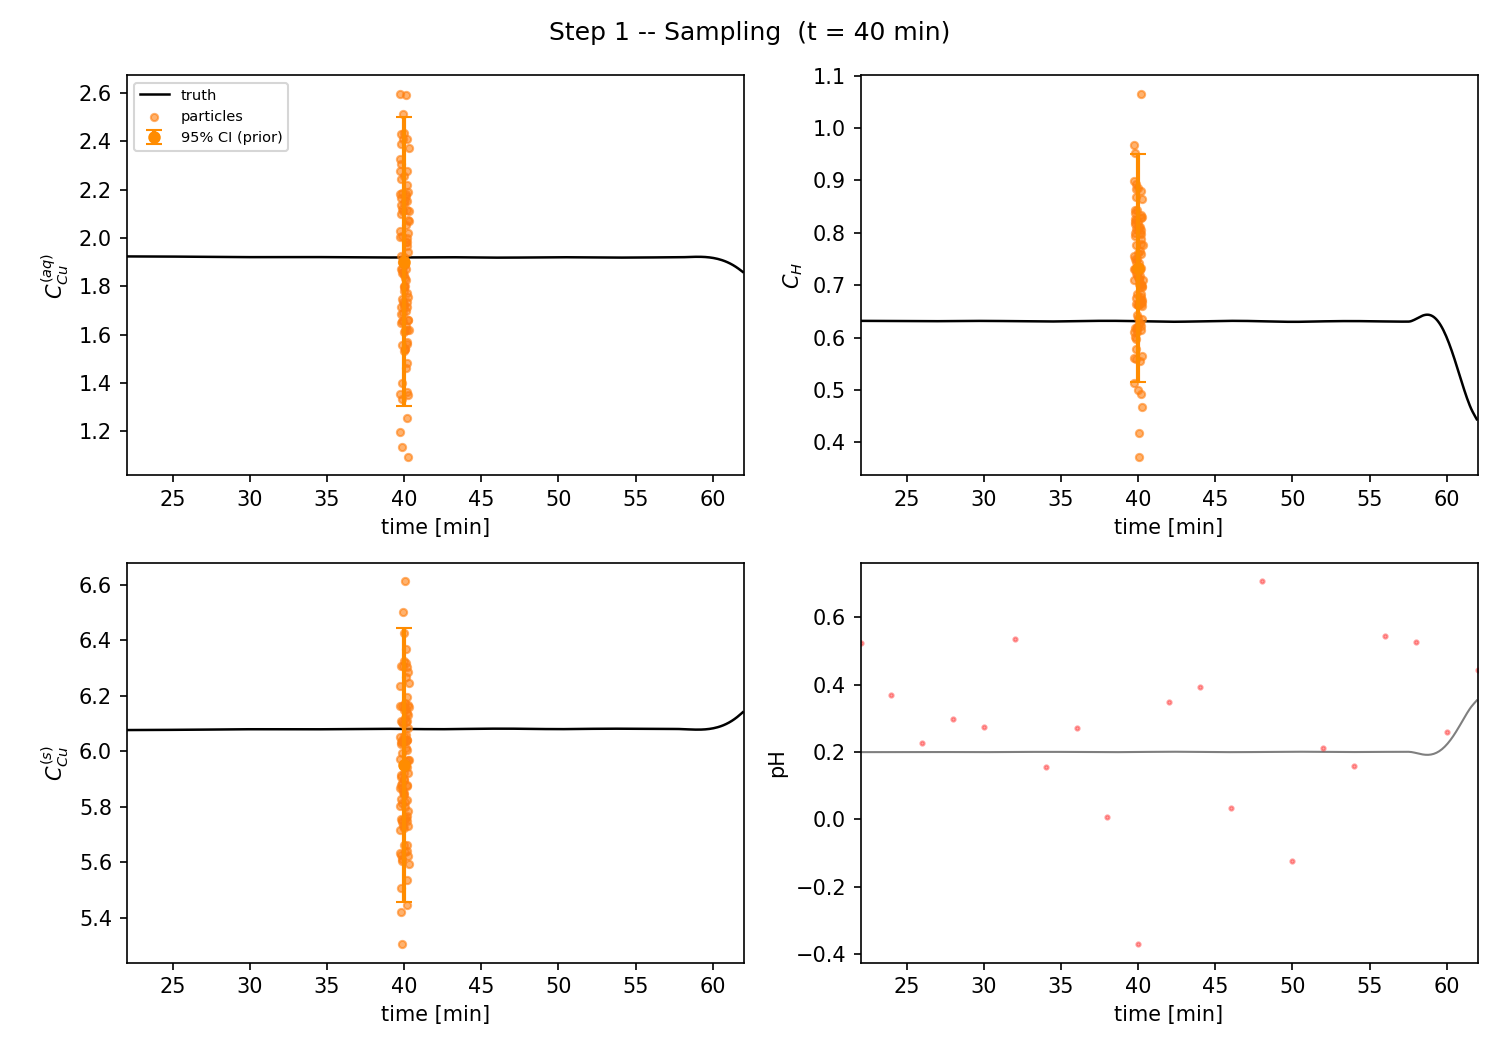

In [25]:
display(Image(filename=f"{OUT}/pf_step1_sampling.png"))


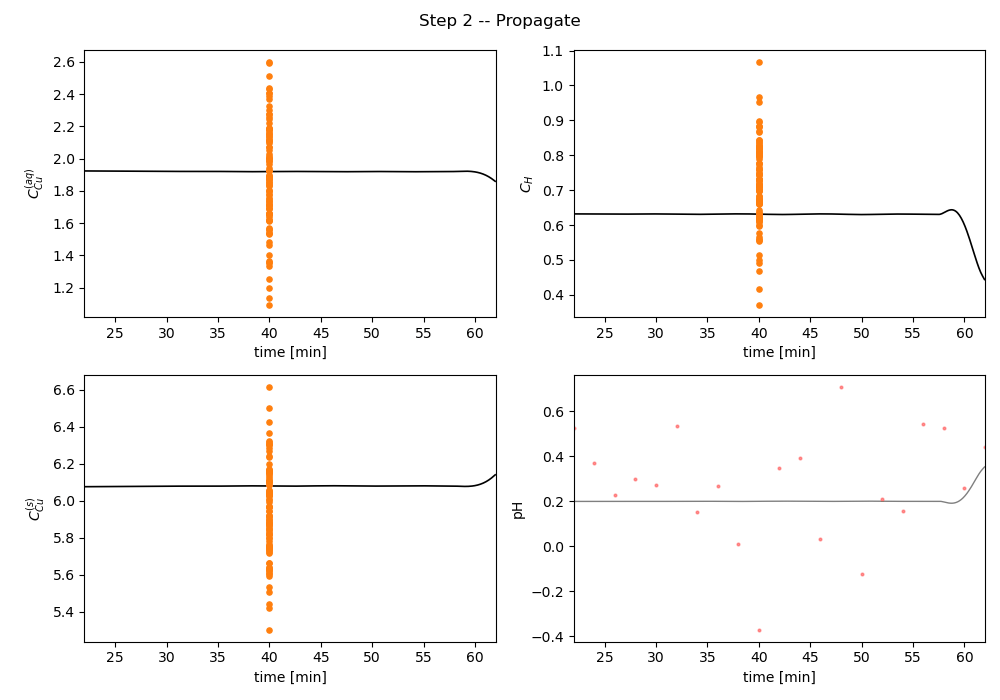

In [26]:
display(Image(filename=f"{OUT}/pf_step2_propagate.gif"))


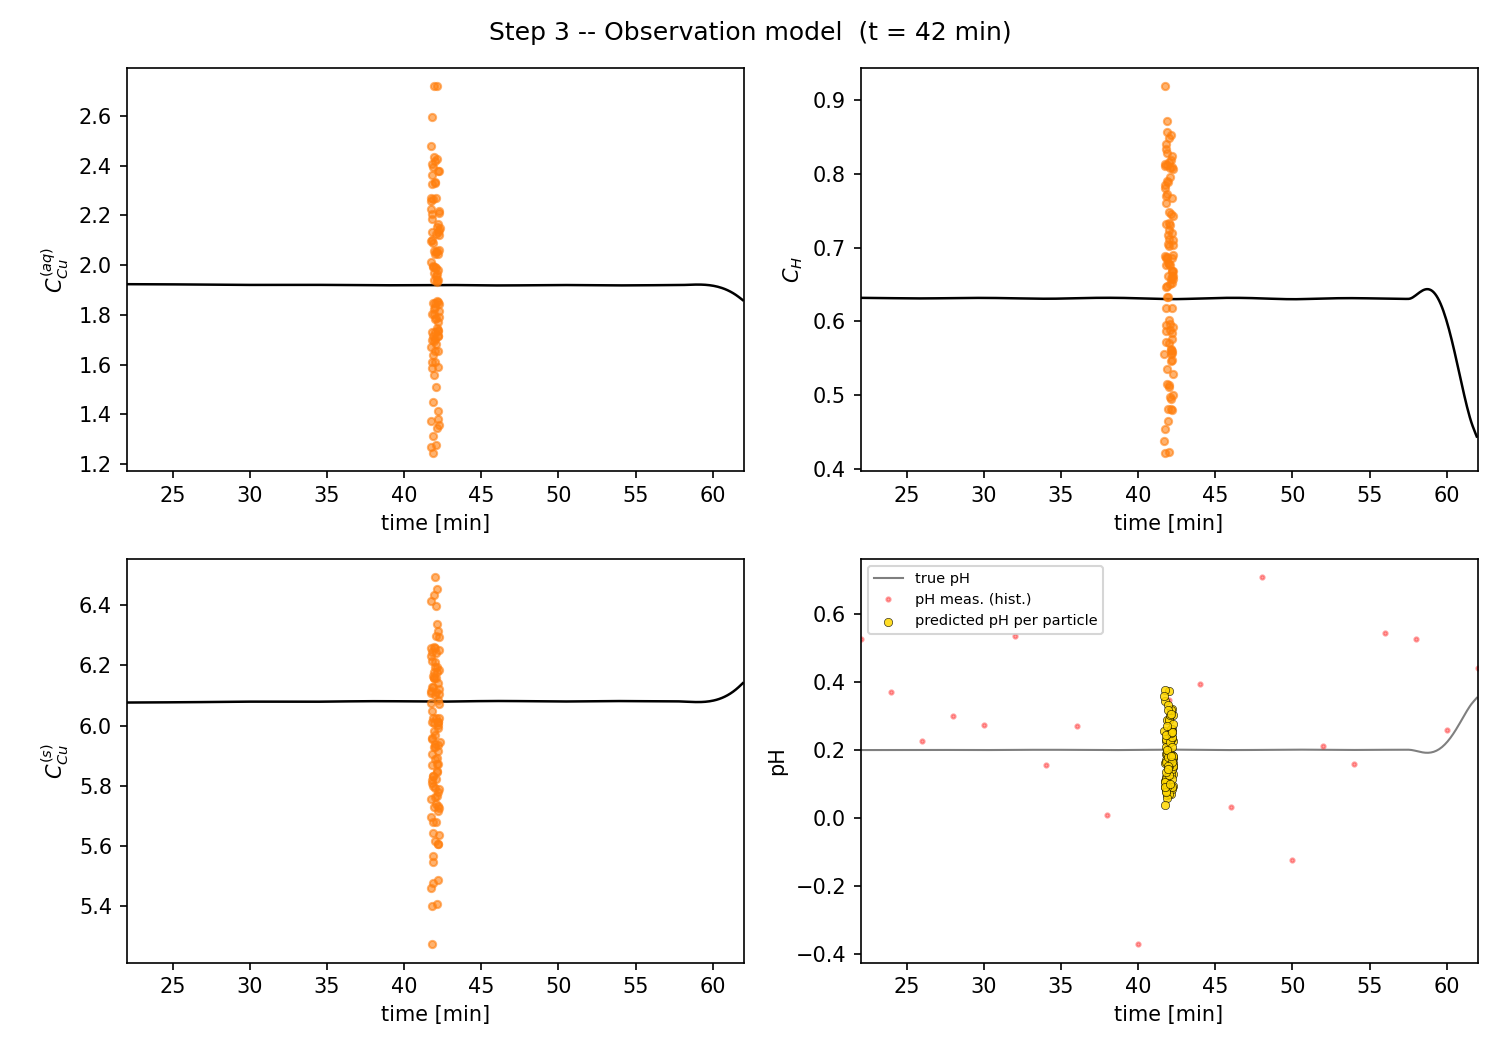

In [27]:
display(Image(filename=f"{OUT}/pf_step3_observation.png"))


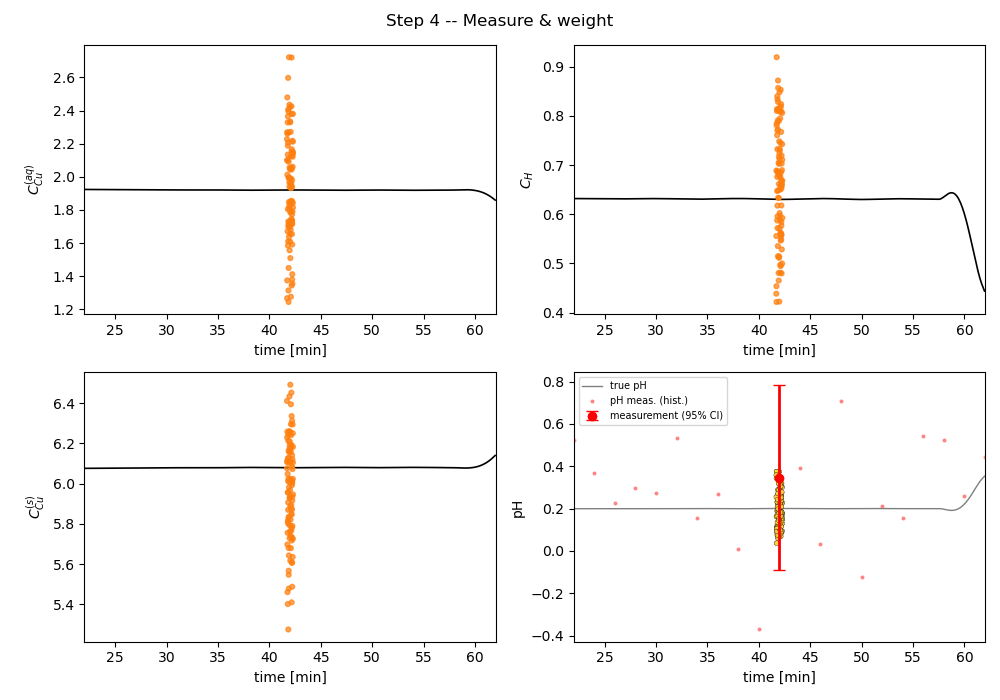

In [28]:
display(Image(filename=f"{OUT}/pf_step4_measure.gif"))


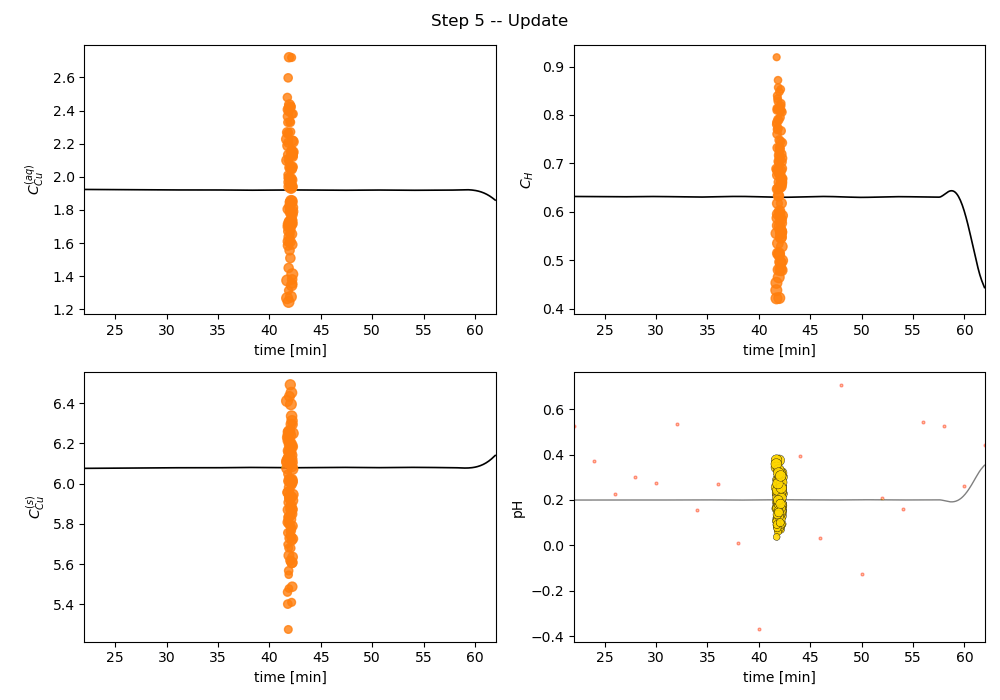

In [29]:
display(Image(filename=f"{OUT}/pf_step5_update.gif"))
